# MuscleMimic reflex-recovery study

Executable research narrative for a spinal-feedback-inspired residual and an independent erroneous exoskeleton torque. The controller is not claimed to be physiologically validated.

# Implementation guide and file map

This front section is the reference map for the complete implementation. All paths below are relative to the repository root `Muscle_model_simulations/musclemimic/`; links use `../` because this notebook lives in `notebooks/`. Generated outputs are evidence artifacts and are not substitutes for reusable Python modules.

## End-to-end architecture

```text
released checkpoint + observation
            |
            v
     frozen base policy -------------------------+
                                                |
joint/contact/pelvis signals -> delay -> reflex |
                                      residual  |
                                                v
stability risk -> recovery gate beta -> recovery policy
                                                |
                                                v
                    safe normalized-action composition
                                                |
                                                v
                    DefaultControl -> muscle data.ctrl

independent phase/event trigger -> joint torque -> data.qfrc_applied
```

The muscle controller and exoskeleton error remain separate by design: controller commands reach MuJoCo through `data.ctrl`, while the disturbance reaches one resolved joint degree of freedom through `data.qfrc_applied`. This separation allows independent logging of cause and response.

## Core environment and execution files

| File | Implementation responsibility |
|---|---|
| [`musclemimic/environments/humanoids/myofullbody.py`](../musclemimic/environments/humanoids/myofullbody.py) | Integrates perturbation triggering, exact joint-DOF torque application, 16-group reflex feature extraction, stance/swing gain blending, residual distribution, rate limiting, action clipping, and CPU/MJX diagnostics. |
| [`musclemimic/environments/base.py`](../musclemimic/environments/base.py) | Defines fixed-shape per-environment carry state for perturbation triggers, prior contacts, reflex residual history, grouped outputs, and saturation diagnostics. |
| [`fullbody/eval.py`](../fullbody/eval.py) | Restores the released policy and exposes reproducible `base_only`, `base_perturbed`, and `base_plus_reflex` evaluation conditions and perturbation/reflex CLI parameters. |
| [`musclemimic/runner/eval_utils.py`](../musclemimic/runner/eval_utils.py) | Runs deterministic exports and saves kinematics, actions, muscle commands, activations, rewards, contacts, torque, onset, reflex groups, saturation, and termination arrays. |
| [`musclemimic/runner/checkpointing.py`](../musclemimic/runner/checkpointing.py) | Canonicalizes standalone Hugging Face Orbax snapshots into an isolated compatible checkpoint tree without mutating downloaded content. |
| [`loco_mujoco/core/visuals/video_recorder.py`](../loco_mujoco/core/visuals/video_recorder.py) | Records comparison videos and falls back to ImageIO's bundled ffmpeg when a system `ffmpeg` executable is unavailable. |
| [`musclemimic/runner/engine.py`](../musclemimic/runner/engine.py) | Existing training/validation engine used by Hydra experiment configurations; also resolves cache/checkpoint runtime context. |

## Reusable reflex-recovery package

| File | Public role |
|---|---|
| [`config.py`](../musclemimic/research/reflex_recovery/config.py) | Typed perturbation, reflex, gate, composer, and top-level configurations with validation. |
| [`perturbations.py`](../musclemimic/research/reflex_recovery/perturbations.py) | One-shot time/phase/heel-strike/stance trigger state, rectangular/half-sine/triangular waveforms, discrete impulse, generalized-force helpers, and anatomical joint resolution. |
| [`muscle_groups.py`](../musclemimic/research/reflex_recovery/muscle_groups.py) | Builds and validates 16 exclusive bilateral groups, creates a differentiable group-to-actuator matrix, distributes commands, and exports CSV/Markdown maps. |
| [`reflex_controller.py`](../musclemimic/research/reflex_recovery/reflex_controller.py) | Computes normalized joint/load/pelvis feedback with stance/swing gains, finite-value protection, saturation, and exact zero-output mode. |
| [`delay_buffer.py`](../musclemimic/research/reflex_recovery/delay_buffer.py) | Implements a vectorized per-environment sensory ring buffer and nearest-control-step delay conversion/reset. |
| [`stability.py`](../musclemimic/research/reflex_recovery/stability.py) | Computes normalized pelvis tilt, angular-velocity, height, contact, and reference-deviation risk components. |
| [`recovery_gate.py`](../musclemimic/research/reflex_recovery/recovery_gate.py) | Converts risk into a low-pass, hysteretic recovery activation `beta` in `[0,1]`. |
| [`rewards.py`](../musclemimic/research/reflex_recovery/rewards.py) | Blends the upstream nominal reward with recovery priorities and relaxes imitation continuously under `beta`. |
| [`terminations.py`](../musclemimic/research/reflex_recovery/terminations.py) | Retains true fall/invalid/timeout conditions and relaxes only reference-deviation termination during recovery, with reason codes. |
| [`recovery_policy.py`](../musclemimic/research/reflex_recovery/recovery_policy.py) | Defines the bounded two-layer grouped-action recovery MLP and parameter counting. |
| [`base_policy.py`](../musclemimic/research/reflex_recovery/base_policy.py) | Provides the stop-gradient wrapper that guarantees the released base-policy parameters remain frozen. |
| [`action_composer.py`](../musclemimic/research/reflex_recovery/action_composer.py) | Composes base, reflex, and gated recovery actions with magnitude/rate/actuator limits and saturation diagnostics. |
| [`metrics.py`](../musclemimic/research/reflex_recovery/metrics.py) | Classifies recovery only after stable support/height/tilt dwell criteria; non-termination alone is insufficient. |
| [`rollout.py`](../musclemimic/research/reflex_recovery/rollout.py) | Loads typed upstream baseline exports and compares deterministic scientific arrays. |
| [`comparison.py`](../musclemimic/research/reflex_recovery/comparison.py) | Loads matched conditions and calculates descriptive reward, height, tilt, contact, impulse, reflex, saturation, and nominal-divergence metrics. |
| [`model_audit.py`](../musclemimic/research/reflex_recovery/model_audit.py) | Audits the exact compiled MuJoCo model and writes bodies, joints, actuators, sensors, contacts, toe mechanics, and action-path evidence. |
| [`plotting.py`](../musclemimic/research/reflex_recovery/plotting.py) | Provides reusable baseline and perturbation-response plotting helpers. |
| [`__init__.py`](../musclemimic/research/reflex_recovery/__init__.py) | Marks the research implementation as an importable package. |

## Configurations, scripts, tests, and documentation

### Hydra configurations

- [`fullbody/conf_reflex_recovery_smoke.yaml`](../fullbody/conf_reflex_recovery_smoke.yaml): 4,096-step integration gate; residual components default off until explicitly enabled.
- [`fullbody/conf_reflex_recovery_train.yaml`](../fullbody/conf_reflex_recovery_train.yaml): conservative phase-2 training configuration with frozen-base intent, perturbation, reflex gains, and small grouped recovery network.
- [`fullbody/conf_reflex_recovery_eval.yaml`](../fullbody/conf_reflex_recovery_eval.yaml): deterministic seeds, saved rollout, and saved-video evaluation settings.
- [`fullbody/conf_reflex_recovery_ablation.yaml`](../fullbody/conf_reflex_recovery_ablation.yaml): controller, imitation, gain-scale, and delay ablation definitions.

### Reproducible scripts

- [`scripts/check_reflex_recovery_environment.py`](../scripts/check_reflex_recovery_environment.py): checks Python, Git, JAX backend/devices, CUDA, MuJoCo, memory, caches, authentication state, and checkpoint resolution without printing tokens.
- [`scripts/audit_myofullbody_model.py`](../scripts/audit_myofullbody_model.py): generates the exact-model audit and group map.
- [`scripts/analyze_reflex_recovery_comparisons.py`](../scripts/analyze_reflex_recovery_comparisons.py): creates the matched metrics CSV and multi-panel comparison plot.

### Tests

The focused suite is in [`tests/reflex_recovery/`](../tests/reflex_recovery/) and covers action composition, frozen parameters, comparison metrics, delay/reset, recovery classification, model audit, muscle groups, perturbations, recovery gate, reflex controller, reward/termination logic, rollout loading, and stability risk. Checkpoint canonicalization is separately covered by [`tests/test_checkpoint_canonicalization.py`](../tests/test_checkpoint_canonicalization.py).

### Design documents

- [`docs/simulation_study.md`](../docs/simulation_study.md): original full study specification and acceptance gates.
- [`docs/reflex_recovery_codebase_audit.md`](../docs/reflex_recovery_codebase_audit.md): repository/action-path audit, baseline command, exact evidence, and implementation decisions.
- [`docs/workflows.md`](../docs/workflows.md): upstream training/evaluation workflow reference.
- [`docs/repository_maintenance.md`](../docs/repository_maintenance.md): Git branching, validation, artifact, upstream-sync, and release workflow.

## Generated evidence and comparison artifacts

| Artifact | Path |
|---|---|
| Exact model audit | `outputs/reflex_recovery/model_audit/` |
| Deterministic baseline arrays | `outputs/reflex_recovery/baseline/` |
| Baseline reproduction arrays | `outputs/reflex_recovery/baseline_repro/` |
| Matched condition rollouts | `outputs/reflex_recovery/comparisons/` |
| Summary metrics | `outputs/reflex_recovery/comparisons/summary.csv` |
| Comparison plot | `outputs/reflex_recovery/comparisons/matched_rollout_comparison.png` |
| H.264 comparison videos | `outputs/reflex_recovery/comparisons/videos/` |
| Local released checkpoints | `outputs/reflex_recovery/checkpoints/` |

These ignored paths are created locally when the corresponding cells or scripts run; they are shown as code rather than repository links because checkpoints, gated data, raw rollouts, and generated videos are not committed. Re-run the scripts/evaluation commands when source, model, checkpoint, motion cache, or configuration changes.

# Phase-by-phase implementation plan

Status meanings: **complete** means implemented and exercised; **partial** means the safe core exists but a named validation or integration gate remains; **open** means no scientific result is claimed yet.

| Phase | Status | Implemented evidence | Remaining work and promotion gate |
|---|---|---|---|
| 0. Environment/setup | **Complete** | Environment checker, H200/JAX verification, authenticated cache/checkpoint, branch and audit record. | Re-run checker whenever node, CUDA, JAX, or checkpoint changes. |
| 1. Project/notebook organization | **Complete** | Importable package, configs, scripts, tests, docs, and this executable notebook. | Keep reusable logic out of notebook cells. |
| 2. Baseline reproduction | **Complete** | Released checkpoint loads; 200-step scientific arrays reproduced bitwise; 700-frame walking video validates visual behavior. | Extend across held-out motions before final claims. |
| 3. Anatomical/action audit | **Complete** | Exact model CSV/Markdown audit, articulated toe evidence, actuator ranges, and safe residual injection point. | Re-audit after any XML/spec/action change. |
| 4. Perturbations | **Partial** | Time, reference phase, and heel-strike one-shot triggers; three waveforms; exact DOF torque; impulse and diagnostics; CPU/MJX-compatible functions. | Validate stance-percentage estimator and complete full modified MJX-step compile. |
| 5. Muscle grouping | **Complete** | 16 exclusive bilateral groups covering 80 lower-body muscles; validated names/indices/weights; differentiable distribution. | Add trunk/arm groups only with an anatomical rationale and new audit. |
| 6. Reflex residual | **Partial** | Joint/reference velocity, contact, pelvis feedback; stance/swing gains; rate/magnitude limits; zero mode; 30 ms delay support. | Tune across low impulses; validate muscle-sensory version 1 normalization before enabling it. |
| 7. Stability/gate | **Partial** | Robust tilt, angular velocity, height, contact, reference risk; sigmoid gate with hysteresis/low-pass behavior. | Add XCoM/margin-of-stability only after coordinate/support-polygon validation. |
| 8. Reward/termination | **Partial** | Nominal/recovery blending, imitation relaxation, true-fall preservation, reference relaxation, reason codes. | Wire every component into residual PPO logging and validate termination distributions. |
| 9. Frozen base/recovery policy | **Partial** | Stop-gradient base wrapper, 24,848-parameter grouped MLP, safe action composer, checkpoint metadata requirements. | Integrate compact recovery observations and produce a trained recovery checkpoint. |
| 10. Curriculum/training | **Open behind gate** | Smoke/train/eval/ablation configs and staged curriculum are documented. | Pass 4,096-step finite-gradient smoke: recovery changes, base remains bitwise frozen, checkpoint restores. |
| 11. Metrics/evaluation | **Partial** | Matched descriptive metrics, explicit recovery dwell classifier, deterministic evidence plots. | Run multiple seeds and motions; report confidence intervals and stratified failures. |
| 12. Ablations | **Specified, not fully executed** | Controller, gain, delay, imitation, joint/side/sign/magnitude/duration/phase grids. | Execute after recovery checkpoint passes; correct for multiple comparisons. |
| 13. Visualization/reporting | **Smoke complete** | Baseline and three matched H.264 videos, multi-panel plots, CSV metrics, embedded notebook narrative. | Add trained recovery and combined-condition videos only after valid training. |
| 14. Acceptance | **Partial** | Core implementation and matched frozen-policy evidence pass; limitations are explicit. | No robust-recovery or physiological-validity claim until open gates close. |

## Recommended execution order

1. Run the environment cell and confirm the project Python, JAX version, and GPU backend.
2. Load the deterministic baseline and inspect its plot/video.
3. Read the exact model/action audit before changing controllers.
4. Run perturbation, muscle-group, reflex/delay, stability/gate, reward/termination, and composer checks in order.
5. Run the real environment integration smoke.
6. Load matched frozen-checkpoint rollouts, plots, and videos.
7. Review limitations and only then run the 4,096-step residual-training gate.
8. After the training gate passes, generate recovery-policy and combined-controller evaluations.
9. Execute multi-seed/multi-motion ablations and report confidence intervals.

In [1]:
from pathlib import Path
import os
import sys

search_roots = (Path.cwd().resolve(), *Path.cwd().resolve().parents)
ROOT = next((p for p in search_roots if (p / 'pyproject.toml').is_file() and (p / 'musclemimic').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Run this notebook from the MuscleMimic repository or one of its subdirectories.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import jax

from musclemimic.research.reflex_recovery.rollout import load_baseline_rollout
from musclemimic.research.reflex_recovery.plotting import plot_baseline_summary
from musclemimic.research.reflex_recovery.model_audit import audit_model

OUTPUT = ROOT / 'outputs' / 'reflex_recovery'
if Path(sys.prefix).resolve() == Path(sys.base_prefix).resolve():
    raise RuntimeError(f'Kernel is not using a virtual environment: {sys.executable}')
print('Python:', sys.executable)
print('JAX:', jax.__version__, jax.default_backend(), jax.devices())
print('Output root:', OUTPUT)

Python: <project-environment>/bin/python
JAX: 0.7.2 gpu [CudaDevice(id=0)]
Output root: <repository>/outputs/reflex_recovery


## Reproduced upstream baseline

**Implementation references:** [`rollout.py`](../musclemimic/research/reflex_recovery/rollout.py), [`checkpointing.py`](../musclemimic/runner/checkpointing.py), [`fullbody/eval.py`](../fullbody/eval.py), [`eval_utils.py`](../musclemimic/runner/eval_utils.py), and [`test_rollout.py`](../tests/reflex_recovery/test_rollout.py). **Generated evidence:** `outputs/reflex_recovery/baseline/` and `outputs/reflex_recovery/baseline_repro/`.

{'steps': 200, 'return': 252.84663212299347, 'dt_s': 0.01, 'actions': (200, 354)}


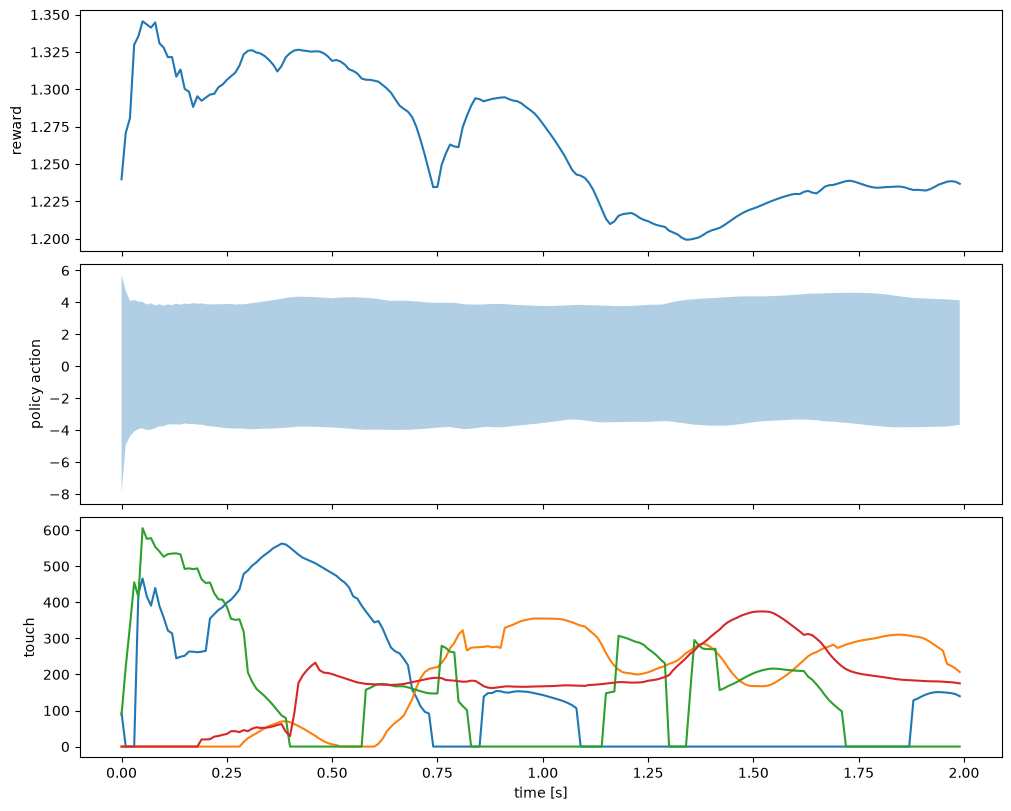

In [2]:
baseline_files = sorted((OUTPUT / 'baseline').glob('*.npz'))
if not baseline_files:
    raise FileNotFoundError('Run the deterministic baseline export described in docs/reflex_recovery_codebase_audit.md')
baseline = load_baseline_rollout(baseline_files[-1])
print({'steps': baseline.num_steps, 'return': baseline.total_reward, 'dt_s': baseline.control_dt_s, 'actions': baseline.policy_actions.shape})
plot_baseline_summary(baseline);

In [3]:
from IPython.display import Video, display
baseline_video = OUTPUT / 'baseline_walking_video' / 'KIT_314_walking_medium09_poses' / 'eval_MyoFullBody_h264.mp4'
if not baseline_video.exists():
    raise FileNotFoundError(f'Baseline video not found: {baseline_video}')
display(Video(str(baseline_video), embed=True, width=960, html_attributes='controls loop muted'))

## Model and controller facts

**Implementation references:** [`model_audit.py`](../musclemimic/research/reflex_recovery/model_audit.py), [`audit_myofullbody_model.py`](../scripts/audit_myofullbody_model.py), [`myofullbody.py`](../musclemimic/environments/humanoids/myofullbody.py), and [`test_model_audit.py`](../tests/reflex_recovery/test_model_audit.py). **Generated evidence:** `outputs/reflex_recovery/model_audit/`.

The exact-model audit is written to `outputs/reflex_recovery/model_audit`. The integrated environment uses 16 exclusive bilateral functional groups (80 lower-body muscles). The residual is added in normalized policy-action space before `DefaultControl` maps commands to actuator ranges.

In [4]:
audit_dir = OUTPUT / 'model_audit'
print('Audit artifacts:', sorted(path.name for path in audit_dir.glob('*')))
print((audit_dir / 'action_path.md').read_text() if (audit_dir / 'action_path.md').exists() else 'Run scripts/audit_myofullbody_model.py')

Audit artifacts: ['action_path.md', 'actuators.csv', 'bodies.csv', 'contacts.csv', 'joints.csv', 'muscle_groups.csv', 'muscle_groups.md', 'sensors.csv', 'sites.csv', 'summary.json', 'toe_audit.md']
# Action Path

The policy emits normalized actions. Residuals are composed and clipped in normalized action space before `DefaultControl.generate_action`, which maps them to compiled actuator control ranges and writes them to `data.ctrl`. External joint torque disturbances remain separate in `data.qfrc_applied`.



## Validated perturbation and reflex configuration

**Configuration references:** [`conf_reflex_recovery_smoke.yaml`](../fullbody/conf_reflex_recovery_smoke.yaml), [`conf_reflex_recovery_train.yaml`](../fullbody/conf_reflex_recovery_train.yaml), [`conf_reflex_recovery_eval.yaml`](../fullbody/conf_reflex_recovery_eval.yaml), and [`conf_reflex_recovery_ablation.yaml`](../fullbody/conf_reflex_recovery_ablation.yaml).

Use `fullbody/conf_reflex_recovery_smoke.yaml` first. Phase triggering was verified against `KIT/314/walking_medium09_poses`: a 0.02 phase target fired at control step 15 on its 773-frame trajectory. Keep long training disabled until the short integrated smoke completes.

In [5]:
smoke_config = ROOT / 'fullbody' / 'conf_reflex_recovery_smoke.yaml'
print(smoke_config.read_text())

defaults:
  - conf_fullbody_gmr
  - _self_

# Short, additive validation configuration. It does not start full training.
wandb:
  mode: offline
  tags: ["reflex-recovery", "smoke"]

experiment:
  seed: 0
  total_timesteps: 4096
  env_params:
    num_envs: 8
    horizon: 500
    perturbation_params:
      enabled: false
      joint: ankle
      side: right
      direction: 1
      magnitude_nm: 10.0
      duration_s: 0.05
      onset_mode: time
      onset_time_s: 1.0
      waveform: half_sine
    reflex_params:
      enabled: false
      scale: 1.0
      group_limit: 0.25
      muscle_limit: 0.25
      rate_limit_per_s: 5.0
      stance_gains: {}
      swing_gains: {}
  ppo_config:
    num_steps: 32
    num_minibatches: 4
  reflex_recovery:
    enabled: true
    base_checkpoint: "hf://amathislab/mm-fullbody-base"
    motion_path: "KIT/314/walking_medium09_poses"
    reflex:
      enabled: false
      scale: 1.0
      delay_s: 0.03
    recovery:
      enabled: false
    perturbation:
  

## Perturbation waveform and impulse verification

**Implementation references:** [`config.py`](../musclemimic/research/reflex_recovery/config.py), [`perturbations.py`](../musclemimic/research/reflex_recovery/perturbations.py), the CPU/MJX hooks in [`myofullbody.py`](../musclemimic/environments/humanoids/myofullbody.py), and [`test_perturbations.py`](../tests/reflex_recovery/test_perturbations.py).

The exoskeleton error is applied through `qfrc_applied`, independently of human muscle commands. This cell checks sign, duration, and discrete torque impulse for every supported waveform.

W0717 16:42:41.560530  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.


rectangular : peak=10.000 Nm, impulse=0.5000 Nms
half_sine   : peak=9.511 Nm, impulse=0.3078 Nms
triangular  : peak=8.000 Nm, impulse=0.2400 Nms


W0717 16:42:42.377155  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.


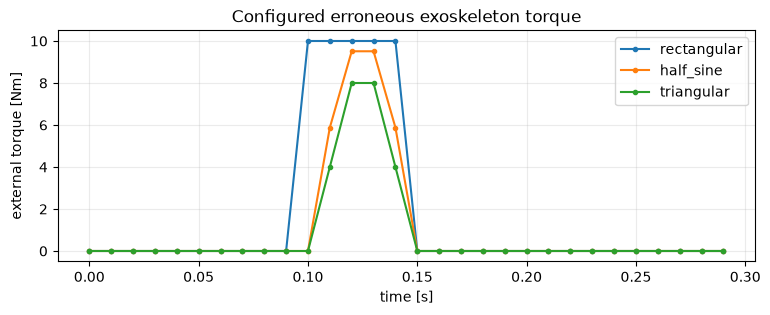

In [6]:
import matplotlib.pyplot as plt
from musclemimic.research.reflex_recovery.perturbations import torque_pulse, discrete_impulse_nms

control_dt = 0.01
time_s = np.arange(0.0, 0.30, control_dt)
waveforms = {}
for waveform in ('rectangular', 'half_sine', 'triangular'):
    torque = np.asarray(torque_pulse(time_s, 0.10, 0.05, 10.0, 1, waveform, backend=np))
    waveforms[waveform] = torque
    impulse = float(discrete_impulse_nms(torque, control_dt))
    print(f'{waveform:12s}: peak={torque.max():.3f} Nm, impulse={impulse:.4f} Nms')
    assert np.count_nonzero(torque) <= 5 and np.all(torque >= 0.0)
fig, ax = plt.subplots(figsize=(9, 3))
for name, torque in waveforms.items(): ax.plot(time_s, torque, marker='.', label=name)
ax.set(xlabel='time [s]', ylabel='external torque [Nm]', title='Configured erroneous exoskeleton torque')
ax.legend(); ax.grid(alpha=0.25);

## Functional muscle-group map

**Implementation references:** [`muscle_groups.py`](../musclemimic/research/reflex_recovery/muscle_groups.py) and [`test_muscle_groups.py`](../tests/reflex_recovery/test_muscle_groups.py). **Generated evidence:** `outputs/reflex_recovery/model_audit/muscle_groups.csv` and `outputs/reflex_recovery/model_audit/muscle_groups.md`.

The initial controller has 16 exclusive bilateral groups. Equal positive weights sum to one within each group; biarticular muscles are assigned once to avoid hidden double counting.

In [7]:
import csv
from collections import defaultdict

group_rows = list(csv.DictReader((audit_dir / 'muscle_groups.csv').open()))
members = defaultdict(list)
for row in group_rows: members[row['group']].append(row['actuator_name'])
assert len(members) == 16
assert len({row['actuator_index'] for row in group_rows}) == len(group_rows)
for group, names in members.items(): print(f'{group:30s} {len(names):2d} muscles: {", ".join(names)}')
print(f'Exclusive mapped lower-body actuators: {len(group_rows)}')

right_hip_flexors               3 muscles: iliacus_r, psoas_r, sart_r
right_hip_extensors             3 muscles: glmax1_r, glmax2_r, glmax3_r
right_hip_abductors             8 muscles: glmed1_r, glmed2_r, glmed3_r, glmin1_r, glmin2_r, glmin3_r, piri_r, tfl_r
right_hip_adductors             7 muscles: addbrev_r, addlong_r, addmagDist_r, addmagIsch_r, addmagMid_r, addmagProx_r, grac_r
right_knee_extensors            4 muscles: recfem_r, vasint_r, vaslat_r, vasmed_r
right_knee_flexors              4 muscles: bflh_r, bfsh_r, semimem_r, semiten_r
right_ankle_plantarflexors      8 muscles: gaslat_r, gasmed_r, soleus_r, tibpost_r, perbrev_r, perlong_r, fdl_r, fhl_r
right_ankle_dorsiflexors        3 muscles: tibant_r, edl_r, ehl_r
left_hip_flexors                3 muscles: iliacus_l, psoas_l, sart_l
left_hip_extensors              3 muscles: glmax1_l, glmax2_l, glmax3_l
left_hip_abductors              8 muscles: glmed1_l, glmed2_l, glmed3_l, glmin1_l, glmin2_l, glmin3_l, piri_l, tfl_l
left_hip

## Reflex controller and sensory-delay checks

**Implementation references:** [`reflex_controller.py`](../musclemimic/research/reflex_recovery/reflex_controller.py), [`delay_buffer.py`](../musclemimic/research/reflex_recovery/delay_buffer.py), reflex integration in [`myofullbody.py`](../musclemimic/environments/humanoids/myofullbody.py), [`test_reflex_controller.py`](../tests/reflex_recovery/test_reflex_controller.py), and [`test_delay_buffer.py`](../tests/reflex_recovery/test_delay_buffer.py).

The controller blends stance and swing gains, then applies group and muscle safety limits. Delays are rounded to the nearest control step. These synthetic checks isolate controller mathematics from simulation dynamics.

W0717 16:42:42.779593  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:42:42.803087  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:42:42.959724  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:42:42.984608  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:42:43.030460  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:42:43.073539  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:42:43.112098  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:42:43.150296  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16

group residual range: -0.07000000029802322 0.03500000014901161
30 ms -> 3 control steps; delayed sequence: [0.0, 0.0, 0.0, 0.0, 1.0, 2.0, 3.0]


W0717 16:42:44.051592  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:42:44.073981  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:42:44.108476  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.


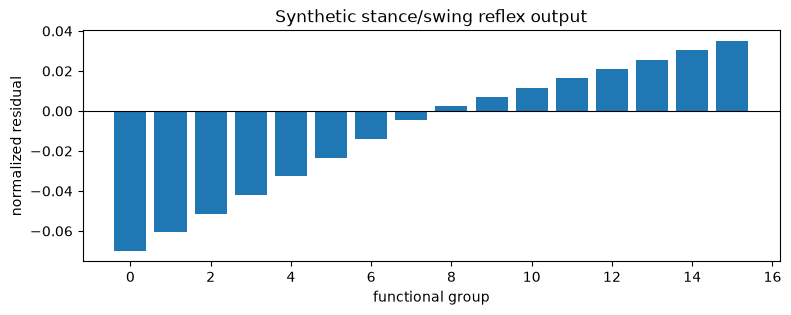

In [8]:
import jax.numpy as jnp
from musclemimic.research.reflex_recovery.reflex_controller import ReflexGains, compute_reflex_action
from musclemimic.research.reflex_recovery.delay_buffer import delay_steps, initialize_delay_buffer, push_and_read

n_groups = 16
z = jnp.zeros(n_groups)
stance_gains = ReflexGains(jnp.full(n_groups, 0.08), jnp.full(n_groups, 0.02), z, z, z, z)
swing_gains = ReflexGains(jnp.full(n_groups, 0.04), jnp.full(n_groups, 0.01), z, z, z, z)
joint_error = jnp.linspace(-1.0, 1.0, n_groups)
joint_velocity = jnp.linspace(0.5, -0.5, n_groups)
stance_weight = jnp.r_[jnp.ones(8), jnp.zeros(8)]
reflex_group = compute_reflex_action(joint_error, joint_velocity, z, z, z, stance_weight, stance_gains, swing_gains, 0.25)
assert reflex_group.shape == (16,) and float(jnp.max(jnp.abs(reflex_group))) <= 0.25
delay = delay_steps(0.03, control_dt); state = initialize_delay_buffer(1, delay + 1, 1)
delayed = []
for sample in range(7):
    state, value = push_and_read(state, jnp.asarray([[float(sample)]]), delay)
    delayed.append(float(value[0, 0]))
print('group residual range:', float(reflex_group.min()), float(reflex_group.max()))
print(f'30 ms -> {delay} control steps; delayed sequence:', delayed)
fig, ax = plt.subplots(figsize=(9, 3)); ax.bar(np.arange(n_groups), np.asarray(reflex_group))
ax.axhline(0, color='black', lw=0.8); ax.set(xlabel='functional group', ylabel='normalized residual', title='Synthetic stance/swing reflex output');

## Stability risk, recovery gate, rewards, and termination

**Implementation references:** [`stability.py`](../musclemimic/research/reflex_recovery/stability.py), [`recovery_gate.py`](../musclemimic/research/reflex_recovery/recovery_gate.py), [`rewards.py`](../musclemimic/research/reflex_recovery/rewards.py), [`terminations.py`](../musclemimic/research/reflex_recovery/terminations.py), and their tests in [`tests/reflex_recovery/`](../tests/reflex_recovery/).

A continuous risk score activates recovery gradually. True fall conditions remain active; only reference-deviation termination is relaxed during recovery.

W0717 16:42:44.258154  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:42:44.278557  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:42:44.321126  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:42:44.365681  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:42:44.407244  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:42:44.451204  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:42:44.491853  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:42:44.537376  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16

peak risk/beta: 2.2377471923828125 0.9959999918937683 minimum imitation weight: 0.20319998264312744


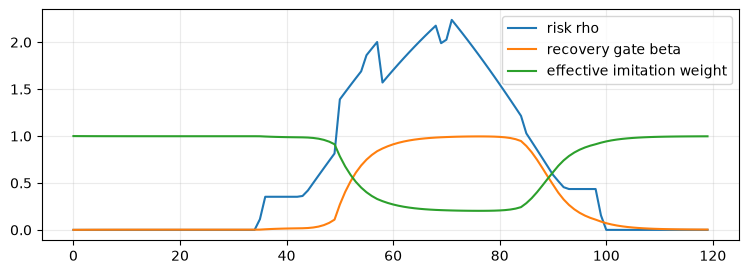

In [9]:
from musclemimic.research.reflex_recovery.stability import compute_stability_risk
from musclemimic.research.reflex_recovery.recovery_gate import update_recovery_gate
from musclemimic.research.reflex_recovery.rewards import blend_rewards
from musclemimic.research.reflex_recovery.terminations import recovery_aware_termination

samples = 120
tilt = np.zeros((samples, 2)); tilt[35:70, 0] = np.linspace(0, 0.65, 35); tilt[70:100, 0] = np.linspace(0.65, 0, 30)
omega = np.zeros((samples, 3)); omega[:, 1] = np.gradient(tilt[:, 0], control_dt)
height = np.ones(samples) * 0.95; height[55:85] -= 0.18
contacts = np.ones((samples, 2)); contacts[50:58] = 0
reference_error = np.zeros(samples); reference_error[40:95] = np.sin(np.linspace(0, np.pi, 55)) * 0.45
risk = compute_stability_risk(jnp.asarray(tilt), jnp.asarray(omega), jnp.asarray(height), jnp.asarray(contacts), jnp.asarray(reference_error), jnp.asarray([1., .5, 1., .5, .5]))
beta = []; previous = jnp.asarray(0.0)
for value in np.asarray(risk.total): previous = update_recovery_gate(jnp.asarray(value), previous); beta.append(float(previous))
beta = np.asarray(beta)
reward = blend_rewards(jnp.ones(samples), jnp.full(samples, 0.5), jnp.asarray(beta), imitation_weight=1.0, imitation_relaxation=0.8, minimum_imitation_weight=0.2)
termination = recovery_aware_termination(jnp.zeros(samples, dtype=bool), jnp.asarray(height), jnp.asarray(np.abs(tilt[:, 0])), jnp.ones(samples, dtype=bool), jnp.asarray(reference_error), jnp.zeros(samples, dtype=bool), jnp.asarray(beta))
assert not bool(jnp.any(termination.done)); print('peak risk/beta:', float(risk.total.max()), beta.max(), 'minimum imitation weight:', float(reward.effective_imitation_weight.min()))
fig, ax = plt.subplots(figsize=(9, 3)); ax.plot(risk.total, label='risk rho'); ax.plot(beta, label='recovery gate beta'); ax.plot(reward.effective_imitation_weight, label='effective imitation weight'); ax.legend(); ax.grid(alpha=.25);

## Recovery policy and safe action composition

**Implementation references:** [`base_policy.py`](../musclemimic/research/reflex_recovery/base_policy.py), [`recovery_policy.py`](../musclemimic/research/reflex_recovery/recovery_policy.py), [`action_composer.py`](../musclemimic/research/reflex_recovery/action_composer.py), [`test_base_policy_frozen.py`](../tests/reflex_recovery/test_base_policy_frozen.py), and [`test_action_composer.py`](../tests/reflex_recovery/test_action_composer.py).

The trainable recovery network outputs only one command per functional group. The released base policy remains frozen; distributed residuals are clipped and rate-limited in normalized action space.

In [10]:
from musclemimic.research.reflex_recovery.recovery_policy import RecoveryPolicy, count_parameters
from musclemimic.research.reflex_recovery.action_composer import compose_action

recovery_model = RecoveryPolicy(num_group_actions=16, hidden_layers=(128, 128))
recovery_params = recovery_model.init(jax.random.key(0), jnp.zeros((1, 48)))
group_recovery = recovery_model.apply(recovery_params, jnp.zeros((1, 48)))
base_action = jnp.zeros((1, 354)); distributed_reflex = jnp.zeros_like(base_action); distributed_recovery = jnp.zeros_like(base_action)
distributed_recovery = distributed_recovery.at[:, :16].set(group_recovery)
composition = compose_action(base_action, distributed_reflex, distributed_recovery, jnp.asarray([0.8]), jnp.zeros_like(base_action), control_dt)
print('recovery parameters:', count_parameters(recovery_params), 'group output:', group_recovery.shape, 'composed action:', composition.action.shape)
assert composition.action.shape == (1, 354) and np.all(np.isfinite(np.asarray(composition.action)))

W0717 16:42:47.100011  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:42:47.138780  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:42:47.219091  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:42:47.313705  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:42:47.380983  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:42:47.426590  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:42:47.903799  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:42:47.991774  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16

recovery parameters: 24848 group output: (1, 16) composed action: (1, 354)


W0717 16:42:49.842800  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:42:49.895908  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.


## Integrated walking-environment smoke

**Implementation references:** [`myofullbody.py`](../musclemimic/environments/humanoids/myofullbody.py), carry fields in [`base.py`](../musclemimic/environments/base.py), the official cache configured by [`check_reflex_recovery_environment.py`](../scripts/check_reflex_recovery_environment.py), and [`conf_reflex_recovery_smoke.yaml`](../fullbody/conf_reflex_recovery_smoke.yaml).

This runs the real MyoFullBody model and official walking cache with a phase-triggered ankle torque plus conservative reflex gains. Zero policy actions are used here to isolate integration plumbing; checkpoint-controlled perturbed rollouts are the next execution stage.

<project-environment>/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO: [MuscleMimic AMASS Retargeting Pipeline] Dataset 1/1: Found existing retargeted motion file at <musclemimic-cache>/AMASS/MyoFullBody/gmr/KIT/314/walking_medium09_poses.npz. Loading ...


W0717 16:42:59.850373  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:42:59.873100  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:42:59.895960  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:42:59.917886  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:42:59.939767  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:42:59.961051  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:42:59.982689  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:43:00.002986  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16

INFO: [MuscleMimic AMASS Retargeting Pipeline] Trajectory data loaded!


W0717 16:43:00.515126  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:43:00.588621  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:43:00.628359  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:43:00.666649  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:43:00.709634  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:43:00.730976  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:43:00.781233  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:43:00.820697  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16

...

[TrajectoryHandler] traj_dt=0.010000 (100.0Hz), control_dt=0.010000 (100.0Hz), cache=sparse


Computing trajectory cache: 100%|██████████| 773/773 [00:00<00:00, 2736.62it/s]
W0717 16:43:02.838866  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:43:02.914946  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.


[TrajectoryHandler] INFO: Materialized sparse trajectory cache at 100.0 Hz


W0717 16:43:03.028848  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:43:03.102528  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:43:03.174292  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:43:03.211059  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:43:03.254541  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:43:03.293735  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:43:03.333786  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16:43:03.372390  399494 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0717 16

torque samples: [61 62 63] peak reflex: 0.10817617923021317 any done: True


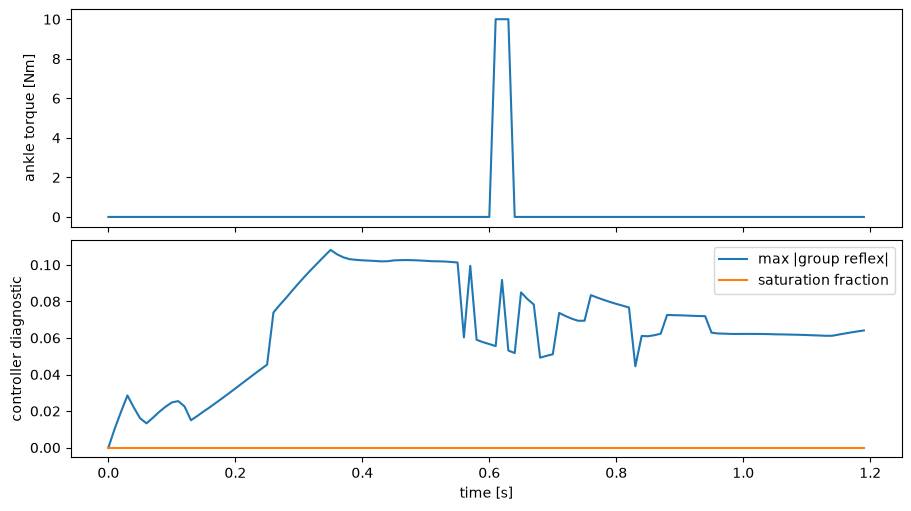

In [11]:
from loco_mujoco.task_factories import ImitationFactory

os.environ['MUSCLEMIMIC_CONVERTED_AMASS_PATH'] = str(ROOT.parent / '.musclemimic' / 'caches' / 'AMASS')
env = ImitationFactory.make(
    'MyoFullBody',
    amass_dataset_conf={'rel_dataset_path': ['KIT/314/walking_medium09_poses'], 'retargeting_method': 'gmr'},
    env_params={
        'headless': True, 'th_params': {'random_start': False, 'fixed_start_conf': (0, 0)},
        'perturbation_params': {'enabled': True, 'joint': 'ankle', 'side': 'right', 'direction': 1, 'magnitude_nm': 10.0, 'duration_s': 0.03, 'onset_mode': 'phase', 'onset_time_s': None, 'onset_phase': 0.08, 'phase_tolerance': 0.001},
        'reflex_params': {'enabled': True, 'stance_gains': {'position': 0.05, 'velocity': 0.01}, 'swing_gains': {'position': 0.03, 'velocity': 0.01}},
    },
)
env.reset(); integrated = []
for step in range(120):
    _, reward_value, _, done, info = env.step(np.zeros(354, dtype=np.float32))
    integrated.append((step * env.dt, reward_value, info['perturbation_torque_nm'], np.max(np.abs(info['reflex_group_action'])), info['reflex_saturation_fraction'], done))
integrated = np.asarray(integrated, dtype=float)
assert np.count_nonzero(integrated[:, 2]) == 3 and np.max(integrated[:, 4]) <= 1.0
print('torque samples:', np.flatnonzero(integrated[:, 2]), 'peak reflex:', integrated[:, 3].max(), 'any done:', bool(integrated[:, 5].any()))
fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True, constrained_layout=True)
axes[0].plot(integrated[:, 0], integrated[:, 2]); axes[0].set_ylabel('ankle torque [Nm]')
axes[1].plot(integrated[:, 0], integrated[:, 3], label='max |group reflex|'); axes[1].plot(integrated[:, 0], integrated[:, 4], label='saturation fraction'); axes[1].set(xlabel='time [s]', ylabel='controller diagnostic'); axes[1].legend();

## Frozen-checkpoint matched comparison

**Implementation references:** condition flags in [`fullbody/eval.py`](../fullbody/eval.py), diagnostic export in [`eval_utils.py`](../musclemimic/runner/eval_utils.py), [`comparison.py`](../musclemimic/research/reflex_recovery/comparison.py), [`analyze_reflex_recovery_comparisons.py`](../scripts/analyze_reflex_recovery_comparisons.py), and [`test_comparison.py`](../tests/reflex_recovery/test_comparison.py). **Generated evidence:** `outputs/reflex_recovery/comparisons/`.

Three deterministic 400-step rollouts use checkpoint `mm-10m-2`, motion `KIT/314/walking_medium09_poses`, seed 0, trajectory index 0, start frame 0, 100 Hz control, and disabled early termination so horizons match. `base_only` has no disturbance. `base_perturbed` receives a right-ankle, positive-direction, 20 Nm half-sine pulse at reference phase 0.20 for 50 ms. `base_plus_reflex` receives the identical pulse and the conservative grouped reflex. These are matched smoke trials, not population statistics.

In [ ]:
from musclemimic.research.reflex_recovery.comparison import load_comparison_rollout, comparison_metrics, pelvis_tilt_rad
comparison_root = OUTPUT / 'comparisons'
condition_names = ('base_only', 'base_perturbed', 'base_plus_reflex')
comparisons = {name: load_comparison_rollout(comparison_root, name) for name in condition_names}
comparison_table = [comparison_metrics(comparisons[name], comparisons['base_only']) for name in condition_names]
for row in comparison_table: print({key: (round(value, 5) if isinstance(value, float) else value) for key, value in row.items()})

### Interpretation of the matched smoke trial

The 20 Nm half-sine pulse has a discretized impulse of about 0.616 Nms. It reduces the frozen-base return by about 1.46 over 400 steps. The initial reflex reduces that loss to about 0.11, while all three runs retain foot contact and pelvis height. However, the reflex run has larger joint-state deviation from nominal and slightly larger peak pelvis tilt. Therefore the correct conclusion is limited: the implementation responds and can improve this trial's reward, but these gains are not yet tuned or validated as robust recovery. The reported saturation fraction includes clipping of the released policy's raw outputs, which commonly exceed `[-1,1]`; it is not solely reflex-induced saturation.

In [ ]:
colors = {'base_only': 'black', 'base_perturbed': 'tab:red', 'base_plus_reflex': 'tab:blue'}
fig, axes = plt.subplots(5, 1, figsize=(11, 13), sharex=True, constrained_layout=True)
for name, rollout in comparisons.items():
    axes[0].plot(rollout.time_s, np.cumsum(rollout.rewards), color=colors[name], label=name)
    axes[1].plot(rollout.time_s, rollout.qpos[:, 2], color=colors[name])
    axes[2].plot(rollout.time_s, pelvis_tilt_rad(rollout.qpos), color=colors[name])
    divergence = np.sqrt(np.mean((rollout.qpos - comparisons['base_only'].qpos) ** 2, axis=-1))
    axes[3].plot(rollout.time_s, divergence, color=colors[name])
    group_peak = np.max(np.abs(rollout.reflex_group_actions), axis=-1) if rollout.reflex_group_actions.size else np.zeros_like(rollout.time_s)
    axes[4].plot(rollout.time_s, group_peak, color=colors[name])
active = np.flatnonzero(np.abs(comparisons['base_perturbed'].perturbation_torque_nm) > 1e-9)
for axis in axes:
    if active.size: axis.axvspan(comparisons['base_perturbed'].time_s[active[0]], comparisons['base_perturbed'].time_s[active[-1]], color='tab:orange', alpha=.2)
axes[0].set_ylabel('cumulative reward'); axes[0].legend(ncol=3)
axes[1].set_ylabel('pelvis height [m]'); axes[2].set_ylabel('pelvis tilt [rad]')
axes[3].set_ylabel('qpos RMSE vs nominal'); axes[4].set_ylabel('max |group reflex|'); axes[4].set_xlabel('time [s]');

### Matched rollout videos

**Implementation references:** recording configuration in [`eval_utils.py`](../musclemimic/runner/eval_utils.py) and codec fallback in [`video_recorder.py`](../loco_mujoco/core/visuals/video_recorder.py). **Generated H.264 files:** `outputs/reflex_recovery/comparisons/videos/`.

The disturbance is not rendered as an object; it enters the selected generalized coordinate through `data.qfrc_applied`. Compare body motion around 1.54 s, the phase-0.20 onset. The translucent purple figure is the reference and the muscle-rendered figure is the controlled model.

In [ ]:
from IPython.display import Markdown
video_root = comparison_root / 'videos'
for name in condition_names:
    path = video_root / name / 'KIT_314_walking_medium09_poses' / 'eval_MyoFullBody_h264.mp4'
    if not path.exists(): raise FileNotFoundError(path)
    display(Markdown(f'#### {name}'))
    display(Video(str(path), embed=True, width=800, html_attributes='controls loop muted'))

## Recovery-policy implementation and training design

**Implementation references:** [`base_policy.py`](../musclemimic/research/reflex_recovery/base_policy.py), [`recovery_policy.py`](../musclemimic/research/reflex_recovery/recovery_policy.py), [`action_composer.py`](../musclemimic/research/reflex_recovery/action_composer.py), and [`conf_reflex_recovery_train.yaml`](../fullbody/conf_reflex_recovery_train.yaml).

The released base network is immutable: its parameter tree is passed through `jax.lax.stop_gradient`. The recovery network has two 128-unit SiLU layers and 16 bounded outputs, one per functional group. Its compact observation should contain pelvis height/orientation/velocity, bilateral hip-knee-ankle states, contact/load features, reference phase, risk components, and previous recovery command. Future disturbance parameters are deliberately excluded. Group commands are distributed through the audited muscle map, multiplied by beta, then composed with the base and reflex signals before `DefaultControl` actuator scaling. Checkpoints must store recovery parameters, optimizer, normalization statistics, configuration, base-checkpoint identity, Git commit, model-audit hash, and muscle map.

A trained recovery-policy comparison is intentionally absent: no residual PPO checkpoint has yet passed the short-training gate. Displaying an untrained random policy as recovery would be scientifically misleading.

## Curriculum and residual PPO protocol

**Execution references:** [`fullbody/experiment.py`](../fullbody/experiment.py), [`runner/engine.py`](../musclemimic/runner/engine.py), [`conf_reflex_recovery_smoke.yaml`](../fullbody/conf_reflex_recovery_smoke.yaml), and [`conf_reflex_recovery_train.yaml`](../fullbody/conf_reflex_recovery_train.yaml).

Training progresses only when the preceding level preserves nominal walking. Level 0 reproduces the frozen base with residuals disabled. Level 1 enables conservative reflex feedback without perturbations and tunes gains without PPO. Level 2 introduces low ankle impulses. Level 3 randomizes ankle magnitude, sign, side, duration, and phase. Level 4 adds knee and hip impulses. Level 5 broadens motion speed/style. Level 6 adds mass, friction, strength, delay, and sensor-noise randomization. Level 7 is held-out evaluation only. PPO updates recovery parameters—and optionally explicitly selected reflex gains—but never base-policy parameters.

Long training must not begin until a 4,096-step smoke produces finite gradients, changing recovery parameters, unchanged base parameters, valid checkpoints, and reproducible evaluation.

In [ ]:
train_config = ROOT / 'fullbody' / 'conf_reflex_recovery_train.yaml'
eval_config = ROOT / 'fullbody' / 'conf_reflex_recovery_eval.yaml'
ablation_config = ROOT / 'fullbody' / 'conf_reflex_recovery_ablation.yaml'
for path in (train_config, eval_config, ablation_config): print(path.relative_to(ROOT))
print('Gated long-training command: python fullbody/experiment.py --config-name=conf_reflex_recovery_train')

## Ablations and parameter sweep

**Implementation references:** [`conf_reflex_recovery_ablation.yaml`](../fullbody/conf_reflex_recovery_ablation.yaml), condition-aware [`fullbody/eval.py`](../fullbody/eval.py), and reusable metrics in [`comparison.py`](../musclemimic/research/reflex_recovery/comparison.py).

Required controller ablations are `base_only`, `base_plus_reflex`, `base_plus_recovery`, and `base_plus_reflex_plus_recovery`, with fixed-versus-relaxed imitation variants after recovery training. Perturbations span hip/knee/ankle, left/right, both directions, multiple magnitudes and durations, and stance/swing phases. Reflex ablations vary gain scale and delay. Toe mechanics remain the audited native articulated MTP condition unless a separately validated model variant is introduced. Every condition uses matched seeds and motion starts.

In [ ]:
from itertools import product
controller_conditions = ('base_only', 'base_plus_reflex', 'base_plus_recovery', 'base_plus_reflex_plus_recovery')
perturbation_grid = list(product(('ankle', 'knee', 'hip'), ('left', 'right'), (-1, 1), (10.0, 20.0), (0.03, 0.05), (0.15, 0.35, 0.65, 0.85)))
evaluation_seeds = (0, 1, 2, 3, 4)
print('controller conditions:', len(controller_conditions))
print('perturbation configurations:', len(perturbation_grid))
print('matched controller-perturbation-seed trials:', len(controller_conditions) * len(perturbation_grid) * len(evaluation_seeds))

## Scientific metrics and recovery definition

**Implementation references:** [`metrics.py`](../musclemimic/research/reflex_recovery/metrics.py), [`comparison.py`](../musclemimic/research/reflex_recovery/comparison.py), [`plotting.py`](../musclemimic/research/reflex_recovery/plotting.py), and [`test_metrics.py`](../tests/reflex_recovery/test_metrics.py). **Generated summary:** `outputs/reflex_recovery/comparisons/summary.csv`.

Non-termination alone is not recovery. A rollout is recovered only after a configurable dwell interval with no non-foot contact, pelvis height above threshold, pelvis tilt below threshold, and restored support. Report recovery probability, time-to-recovery, falls, exact termination reason, minimum pelvis height, peak roll/pitch and angular velocity, contact sequence, tracking deviation, perturbation impulse, reflex/recovery magnitude, action saturation, rate-limit violations, reward components, and nominal degradation. Confidence intervals must be computed across seeds and motions; the deterministic trial above has no confidence interval and remains labeled a smoke result.

In [ ]:
from musclemimic.research.reflex_recovery.metrics import classify_recovery
dwell_steps = 25
example = classify_recovery(
    non_foot_contact=jnp.zeros((1, 100), dtype=bool),
    pelvis_height_m=jnp.r_[jnp.full(20, .5), jnp.full(80, .9)][None, :],
    pelvis_tilt_rad=jnp.r_[jnp.full(20, .8), jnp.full(80, .1)][None, :],
    stable_support=jnp.r_[jnp.zeros(20, dtype=bool), jnp.ones(80, dtype=bool)][None, :],
    minimum_height_m=.7, maximum_tilt_rad=.4, dwell_steps=dwell_steps,
)
print('example recovered:', bool(example.recovered[0]), 'first stable dwell completion:', int(example.recovery_step[0]))

## Reproducibility record

**Reference files:** [`reflex_recovery_codebase_audit.md`](../docs/reflex_recovery_codebase_audit.md), [`checkpointing.py`](../musclemimic/runner/checkpointing.py), and [`test_checkpoint_canonicalization.py`](../tests/test_checkpoint_canonicalization.py). **Generated exact audit:** `outputs/reflex_recovery/model_audit/summary.json`.

The baseline uses checkpoint `amathislab/mm-10m-2`, locally restored at step 12,500, and official GMR cache `KIT/314/walking_medium09_poses` (773 frames, 100 Hz). Its scientific arrays were bitwise reproducible. The exact audit records 89 qpos, 88 qvel, 354 actuators, 102 bodies, 83 joints, 2,038 sites, 110 sensors, and articulated bilateral MTP joints with range ±0.523599 rad, damping 0.5, armature 0.01, and zero stiffness. The H200 environment uses JAX 0.7.2. Authentication secrets are never written to code, notebook, configuration, or output metadata.

In [ ]:
import hashlib
motion_cache = ROOT.parent / '.musclemimic' / 'caches' / 'AMASS' / 'MyoFullBody' / 'gmr' / 'KIT' / '314' / 'walking_medium09_poses.npz'
checkpoint_metadata = OUTPUT / 'checkpoints' / 'mm-10m-2' / '_CHECKPOINT_METADATA'
def sha256(path):
    digest = hashlib.sha256()
    with path.open('rb') as file:
        for block in iter(lambda: file.read(1024 * 1024), b''): digest.update(block)
    return digest.hexdigest()
print('motion SHA256:', sha256(motion_cache))
print('checkpoint metadata SHA256:', sha256(checkpoint_metadata))
print('comparison artifacts:', sorted(path.name for path in comparison_root.glob('*') if path.is_file()))

## Acceptance status and honest limitations

**Source specification:** [`simulation_study.md`](../docs/simulation_study.md). **Verification:** [`tests/reflex_recovery/`](../tests/reflex_recovery/), [`test_checkpoint_canonicalization.py`](../tests/test_checkpoint_canonicalization.py), the comparison plot, CSV, and H.264 videos linked above.

**Completed gates:** environment/GPU verification; authenticated checkpoint and motion access; deterministic upstream baseline; exact model/action audit; independent generalized-force perturbations; time, phase, and heel-strike triggers; 16-group muscle map; vectorized reflex, delay, stability, gate, reward, termination, and recovery-classification modules; recovery-network architecture; safe action composition; matched frozen-checkpoint rollouts; comparison plots; and synchronized videos.

**Open gates:** stance-percentage triggering needs a validated stance-duration estimator; muscle-sensory reflex version 1 needs signal normalization validation; recovery observations need an integrated environment adapter; residual PPO training/checkpointing needs a finite-gradient smoke; `base_plus_recovery` and combined trained-policy videos require that checkpoint; full multi-seed/multi-motion sweeps and confidence intervals have not run; full modified MJX-step compilation remains expensive and requires separate validation. The controller remains **spinal-feedback-inspired**, not physiologically validated. These limitations prevent claiming robust recovery or human validity today.